In [5]:
# %matplotlib ipympl

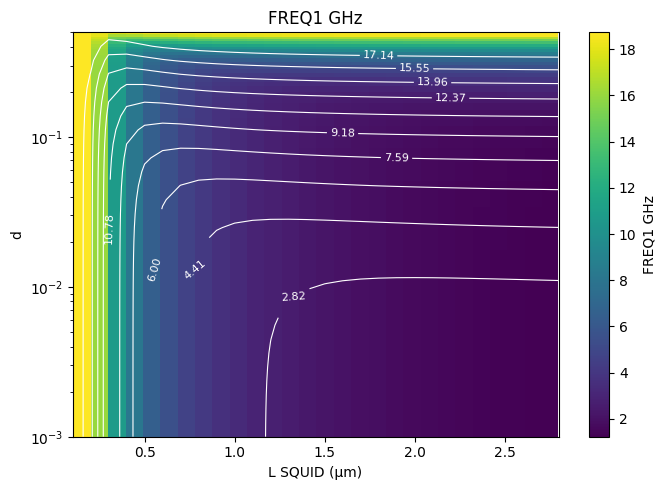

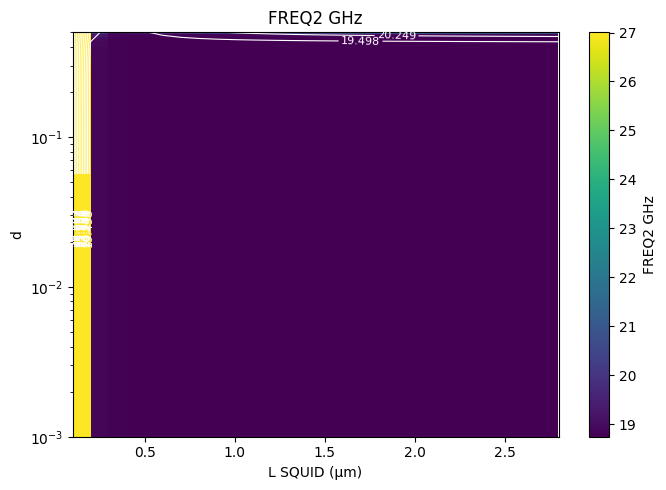

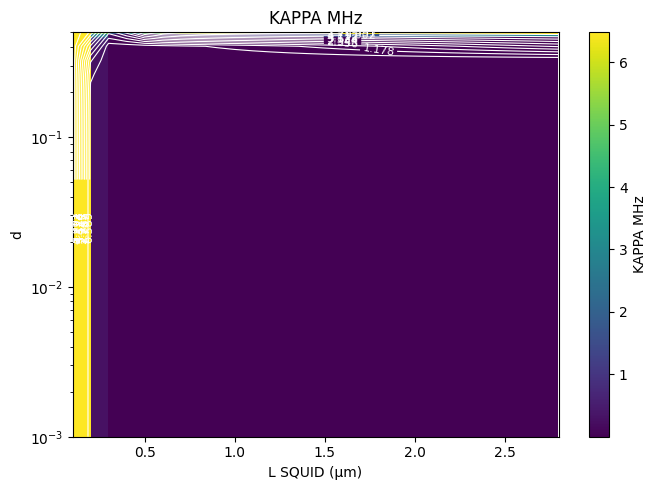

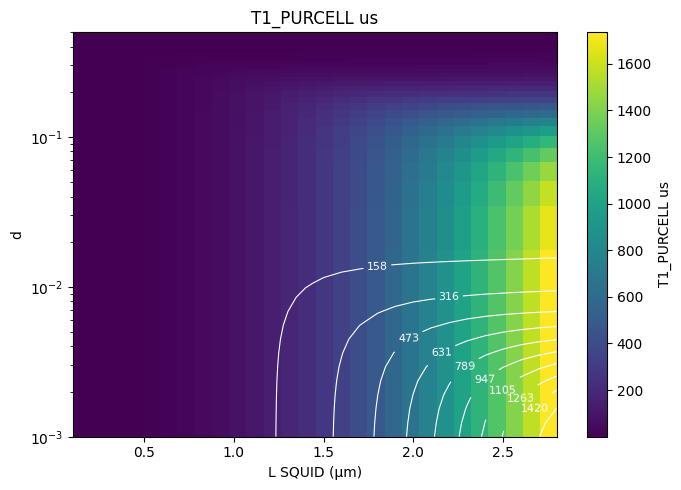

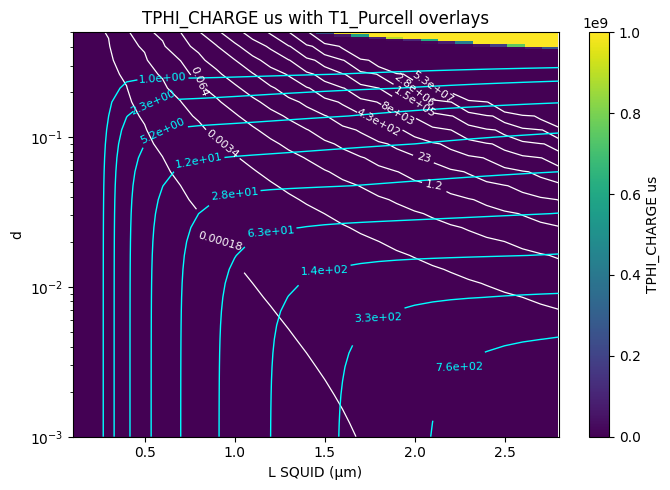

C:\Users\gusarov\AppData\Local\Temp\ipykernel_149528\3055202914.py:70: RuntimeWarning: All-NaN slice encountered
  levels = np.linspace(np.nanmin(Z), np.nanmax(Z), 12)


ValueError: cannot convert float NaN to integer

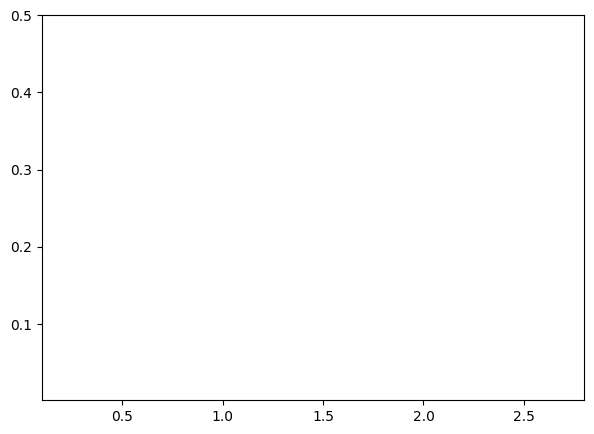

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("chain_resonator_purcell_charge_nonsym.csv")

params = [
    "FREQ1 GHz",
    "FREQ2 GHz",
    "KAPPA MHz",
    "T1_PURCELL us",
    "TPHI_CHARGE us",
    "G_COUPLING MHz"
]

L_vals = np.sort(df["L SQUID um"].unique())
d_vals = np.sort(df["d"].unique())

X, Y = np.meshgrid(L_vals, d_vals)

# Precompute Purcell grid once for overlay
pivot_purcell = df.pivot(index="d", columns="L SQUID um", values="T1_PURCELL us")
Z_purcell = pivot_purcell.values

for p in params:
    pivot = df.pivot(index="d", columns="L SQUID um", values=p)
    Z = pivot.values

    plt.figure(figsize=(7, 5))

    im = plt.imshow(
        Z,
        origin="lower",
        aspect="auto",
        extent=[L_vals.min(), L_vals.max(), d_vals.min(), d_vals.max()]
    )

    if p == "TPHI_CHARGE us":
        # Charge contours in log scale
        vmin_charge = np.nanmin(Z[Z > 0])
        vmax_charge = np.nanmax(Z)
        levels_charge = np.logspace(np.log10(vmin_charge), np.log10(vmax_charge), 12)

        cs_charge = plt.contour(
            X, Y, Z,
            levels=levels_charge,
            colors="white",
            linewidths=0.9
        )
        plt.clabel(cs_charge, inline=True, fontsize=8, fmt="%.2g")

        # Purcell contours overlaid in a different color
        vmin_p = np.nanmin(Z_purcell[Z_purcell > 0])
        vmax_p = np.nanmax(Z_purcell)
        # Purcell contours overlaid in a different color
        levels_p = np.logspace(0, np.log10(np.nanmax(Z_purcell)), 10)

        cs_purcell = plt.contour(
            X, Y, Z_purcell,
            levels=levels_p,
            colors="cyan",
            linewidths=1.0
        )

        plt.clabel(cs_purcell, inline=True, fontsize=8, fmt="%.1e")

        plt.title(f"{p} with T1_Purcell overlays")

    else:
        levels = np.linspace(np.nanmin(Z), np.nanmax(Z), 12)
        cs = plt.contour(X, Y, Z, levels=levels, colors="white", linewidths=0.8)
        plt.clabel(cs, inline=True, fontsize=8)

        plt.title(p)

    plt.colorbar(im, label=p)
    plt.xlabel("L SQUID (µm)")
    plt.ylabel("d")
    plt.yscale("log")
    plt.tight_layout()
    plt.show()